# What is DASK UI?

Dask UI is a web-based user interface that provides visualizations and diagnostic information for Dask distributed computing workflows. Dask UI helps us to better understand and optimize the Dask workflows.

**REFERENCE**: https://docs.dask.org/en/stable/dashboard.html

In [ ]:
import dask
from dask.distributed import Client
import dask.dataframe as dd  # now works


#### The Client is the primary entry point for users of dask.distributed. When we create a Client object it registers itself as the default Dask scheduler. All .compute() methods will automatically start using the distributed system.

In [ ]:
client = Client(n_workers = 2, threads_per_worker = 2, processes=True, memory_limit='3GB')

In [ ]:
client

#### STATUS TAB-Shows the following 4 things:
* Bytes Stored and Bytes per Worker: Cluster memory and Memory per worker

* Task Processing/CPU Utilization/Occupancy/Data Transfer: Tasks being processed by each worker/ CPU Utilization per worker/ Expected runtime for all tasks currently on a worker.

* Task Stream: Individual task across threads.

* Progress: Progress of a set of tasks.

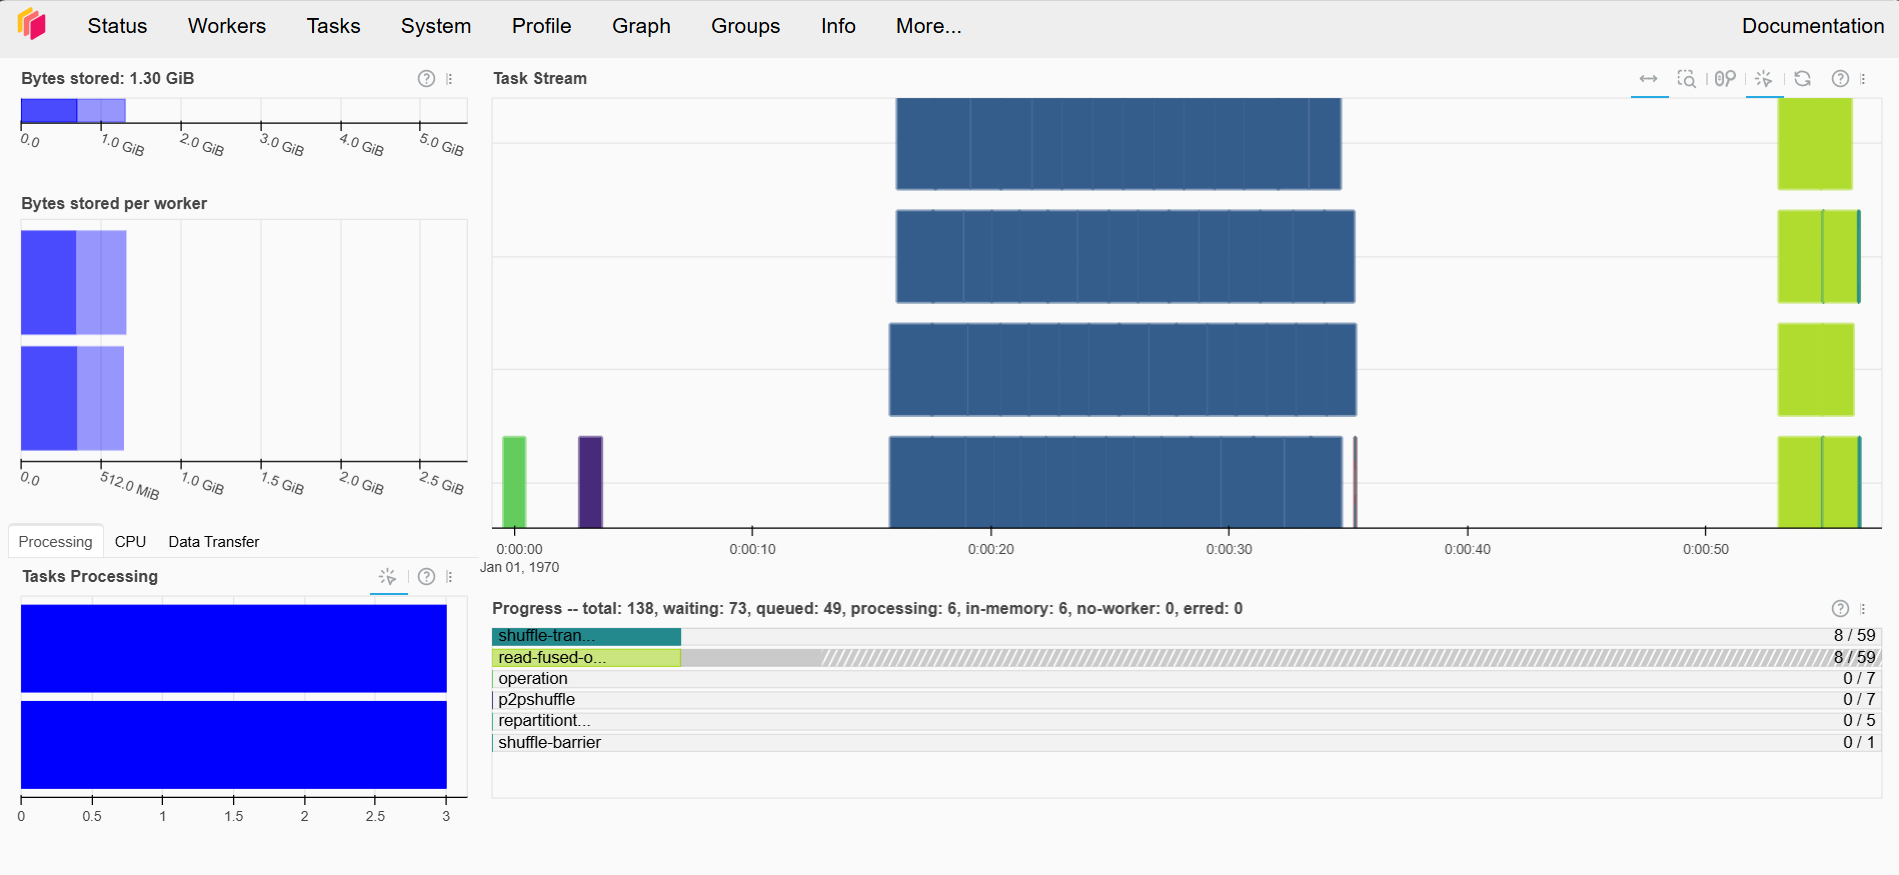

In [ ]:
df = dd.read_csv("Airline_2016_2018.csv", dtype={'CANCELLATION_CODE': 'object'} )
df = df.repartition(npartitions=20)

In [ ]:
df = df[['OP_CARRIER', 'ORIGIN', 'DEST', 'AIR_TIME']]

In [ ]:
df.head(10)

In [ ]:
df = df[df['AIR_TIME'] < 360]

In [ ]:
df.head()

#### WORKERS - Gives the CPU usage, memory usage and other metrics for each worker in the cluster.

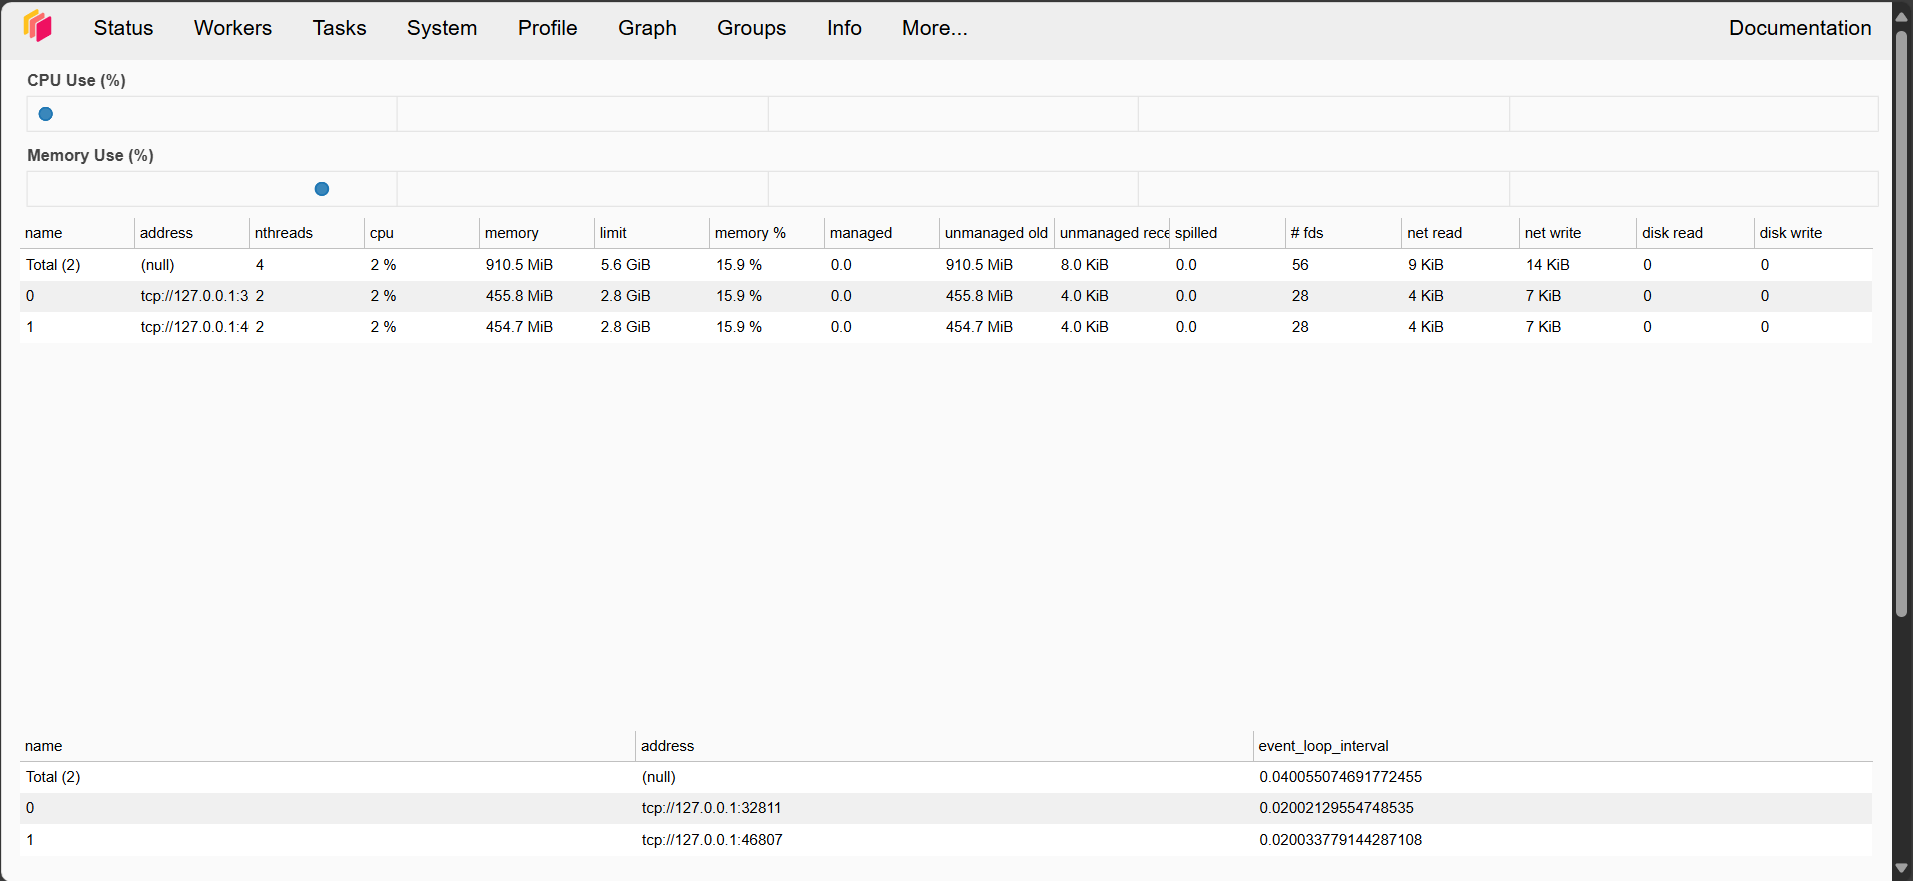

#### System Tab gives CPU, memory and bandwidth statistics for the cluster.

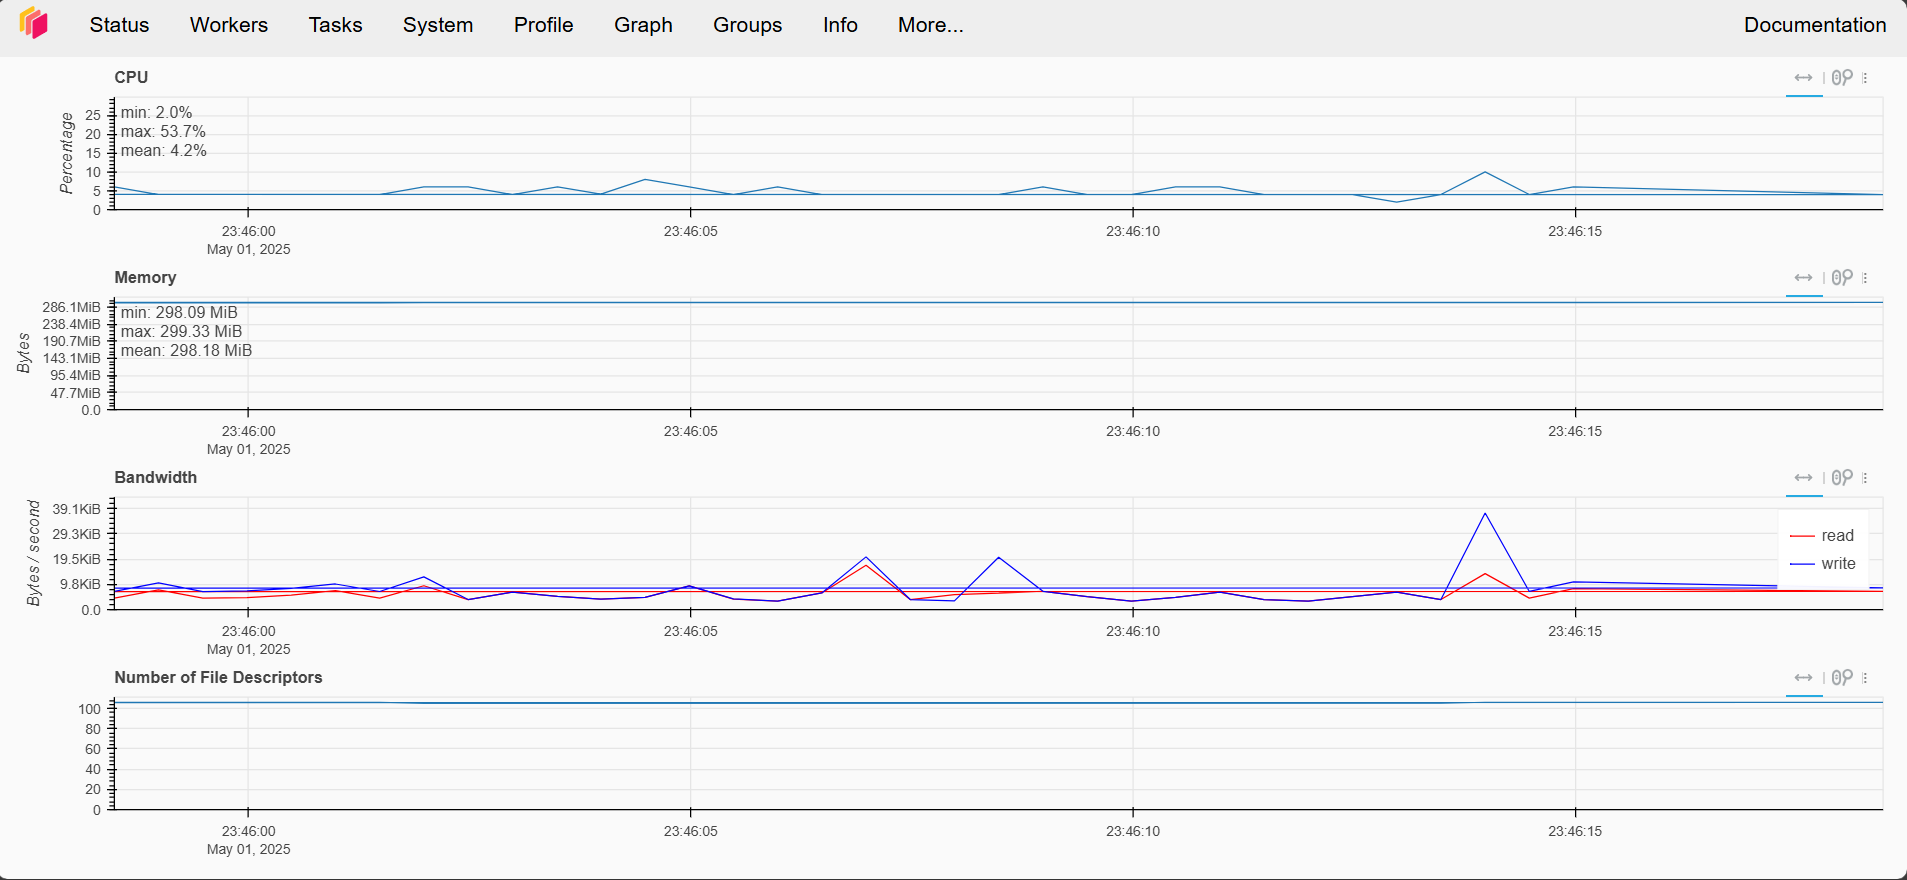

#### Tasks: This tab lists all of the tasks that are currently running in our cluster across the threads as Task Stream. For each task, it shows the task name/description

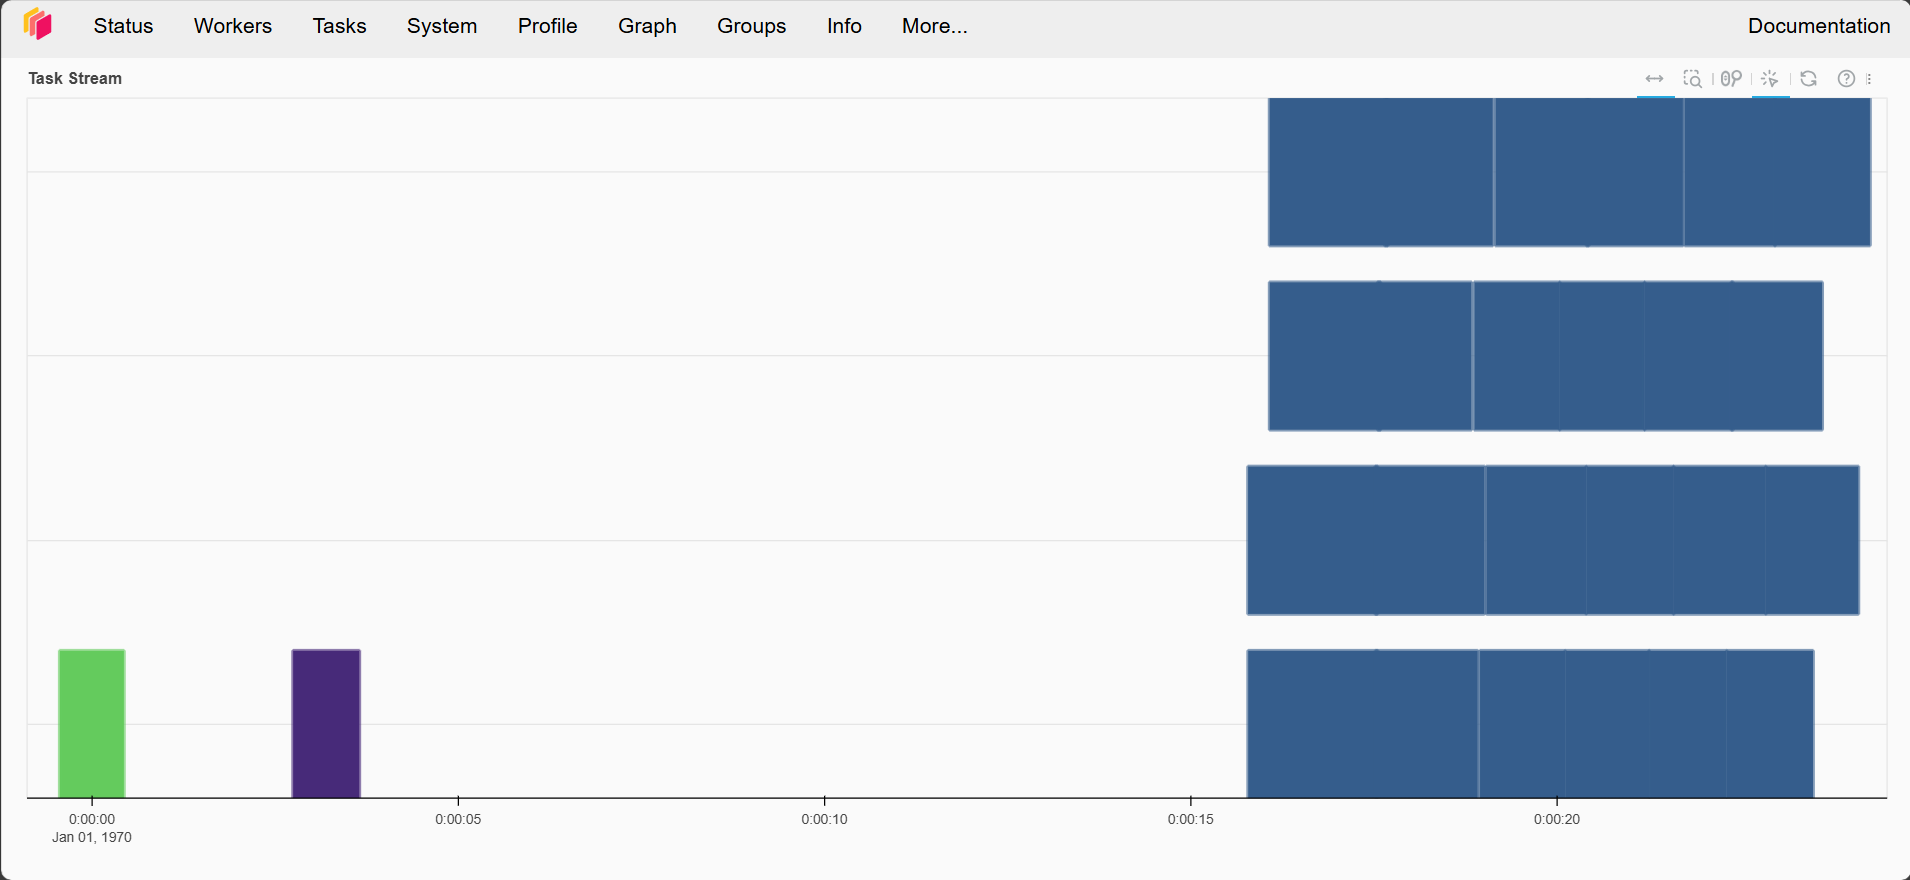

#### Profile: This tab displays profiling information for each task in the Dask cluster. Profiling is a technique used to measure the performance of a program by analyzing its execution behavior. This tab shows the execution time for each task in the cluster, allowing users to identify performance bottlenecks and optimize their code.

**NOTE**: The profile tab is not compatible with CPython v3.11, so it displays profiling information for a default task not related to the user's workload.

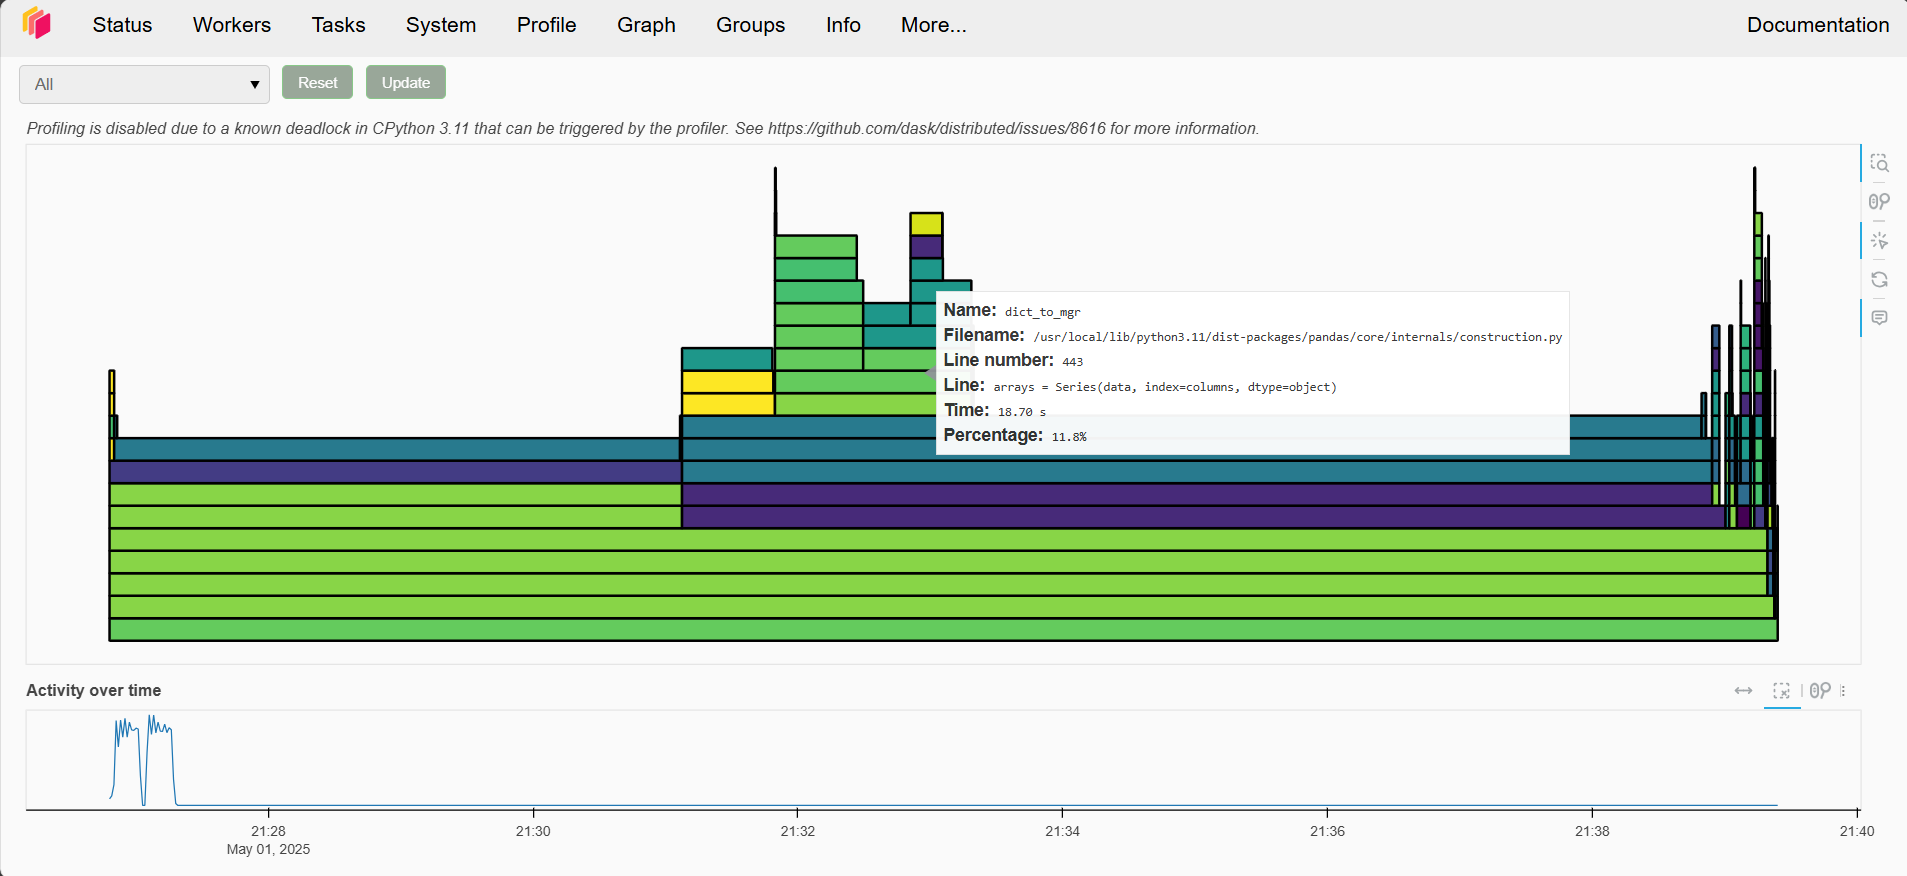

In [ ]:
df.OP_CARRIER.count().compute()

In [ ]:
print(df.npartitions)

In [ ]:
df.groupby('OP_CARRIER')["AIR_TIME"].mean().visualize(engine='graphviz')

In [ ]:
df.groupby('OP_CARRIER').AIR_TIME.mean().compute()


#### GRAPH Tab- The graph view provides a visual representation of the computational graph that describes the dependencies between the different tasks in the computation. It allows us to explore the structure of the computation and identify any bottlenecks or areas of inefficiency.

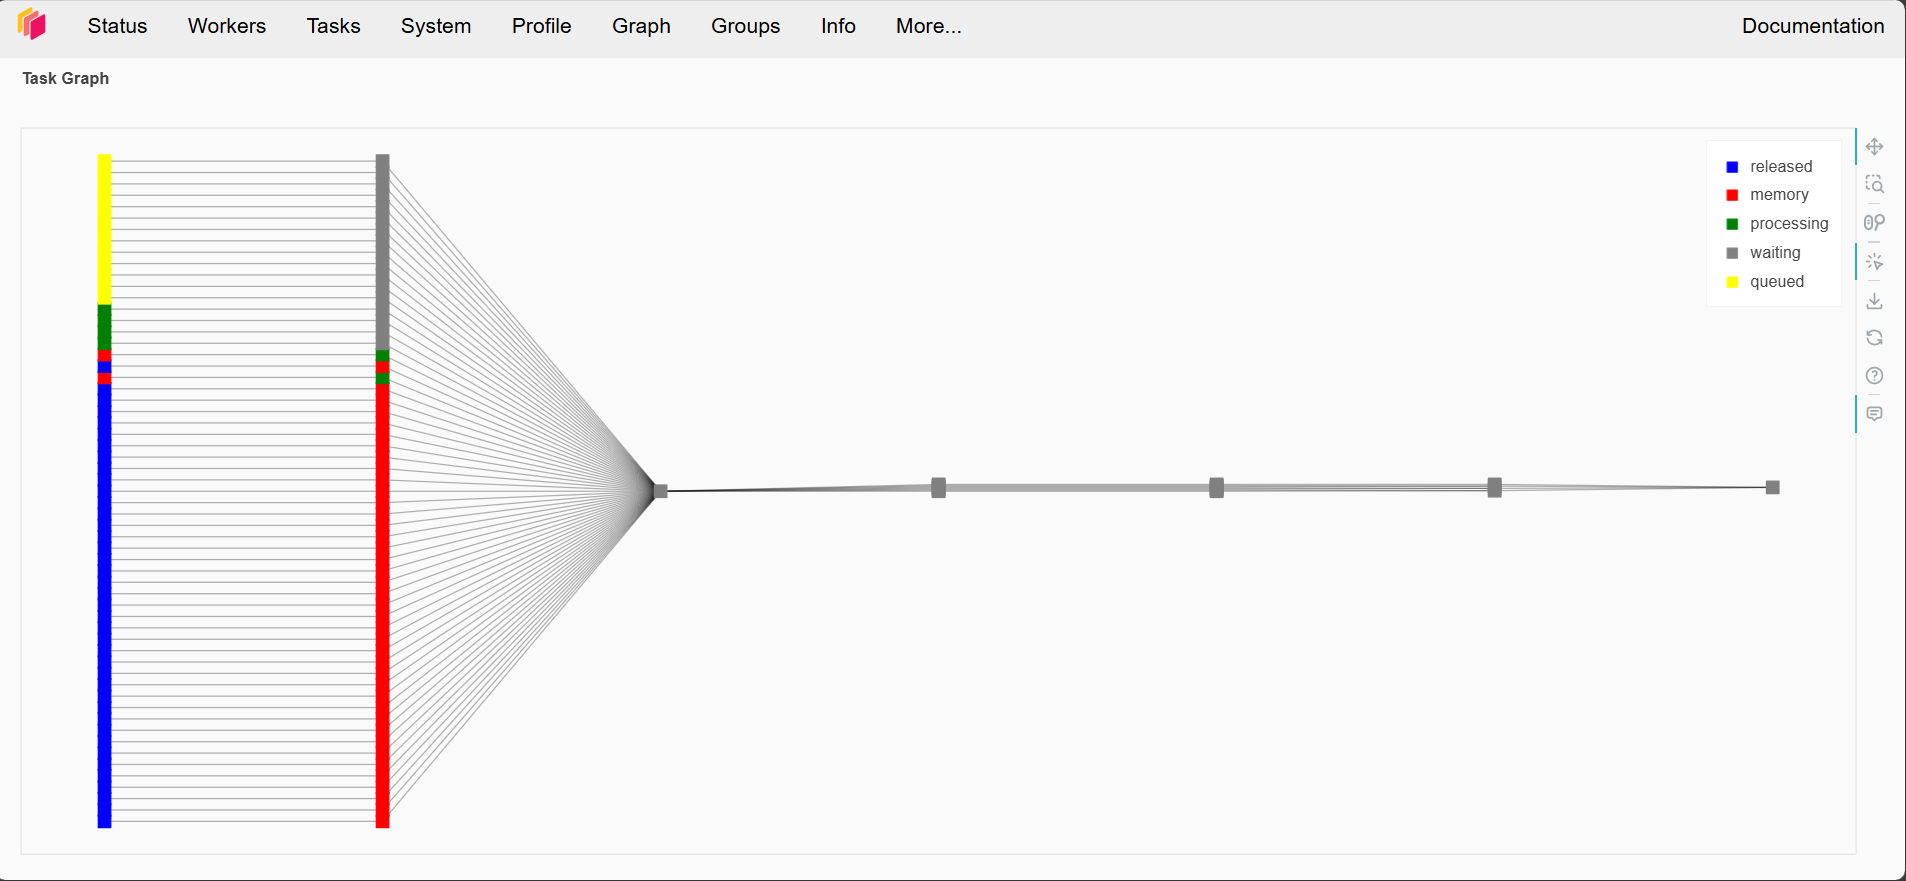

#### Info: This tab provides general information about the Dask cluster, such as the number of workers and the amount of memory and CPU available. It also shows the current status of each worker in the cluster, including its IP address, CPU usage, and memory usage.

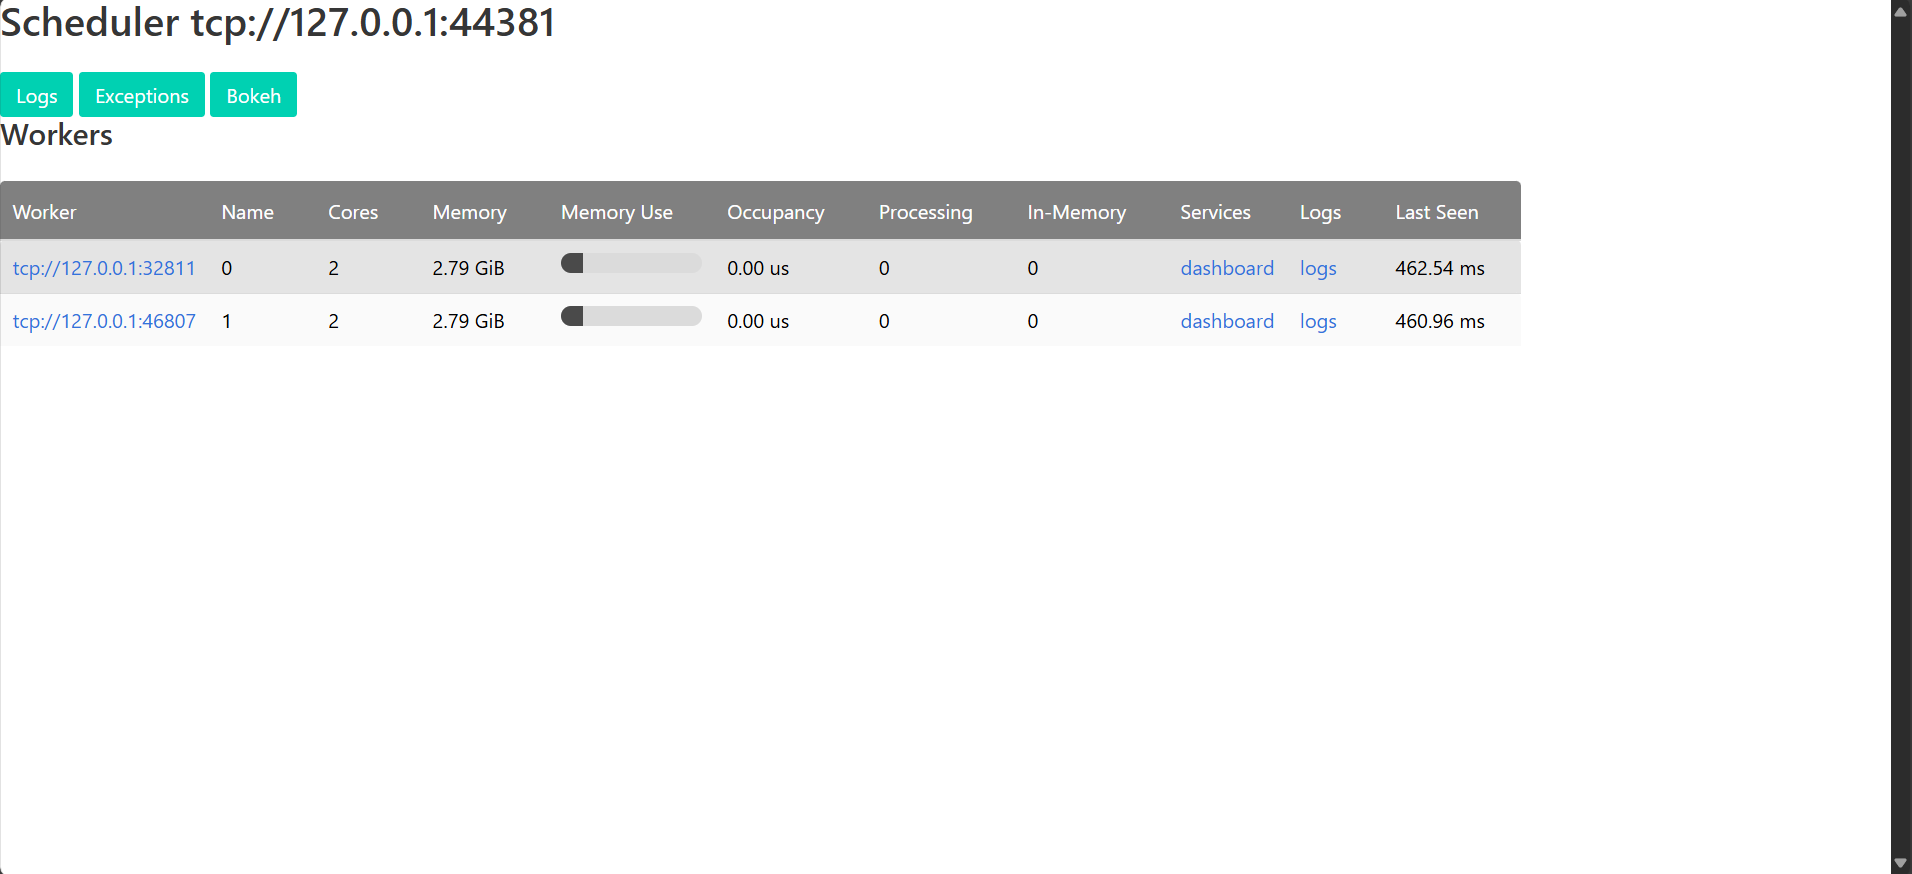

#### We can find many more relevant metrics of interest provided by Dask UI under the 'More' Tabs.

In [ ]:
client.shutdown()